🔍 Searching for dataset folders...

📊 DATASET AUDIT REPORT
✅ Total Classes: 22 | Total Images: 32534


,Folder_Name,Image_Count
0,Late_blight,792
1,Tomato_Yellow_Leaf_Curl_Virus,498
2,Septoria_leaf_spot,746
3,Early_blight,643
4,Spider_mites Two-spotted_spider_mite,435
5,powdery_mildew,252
6,healthy,805
7,Bacterial_spot,732
8,Target_Spot,457
9,Tomato_mosaic_virus,584


/tmp/ipykernel_55/4062601743.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_audit, x='Image_Count', y='Folder_Name', palette='viridis')


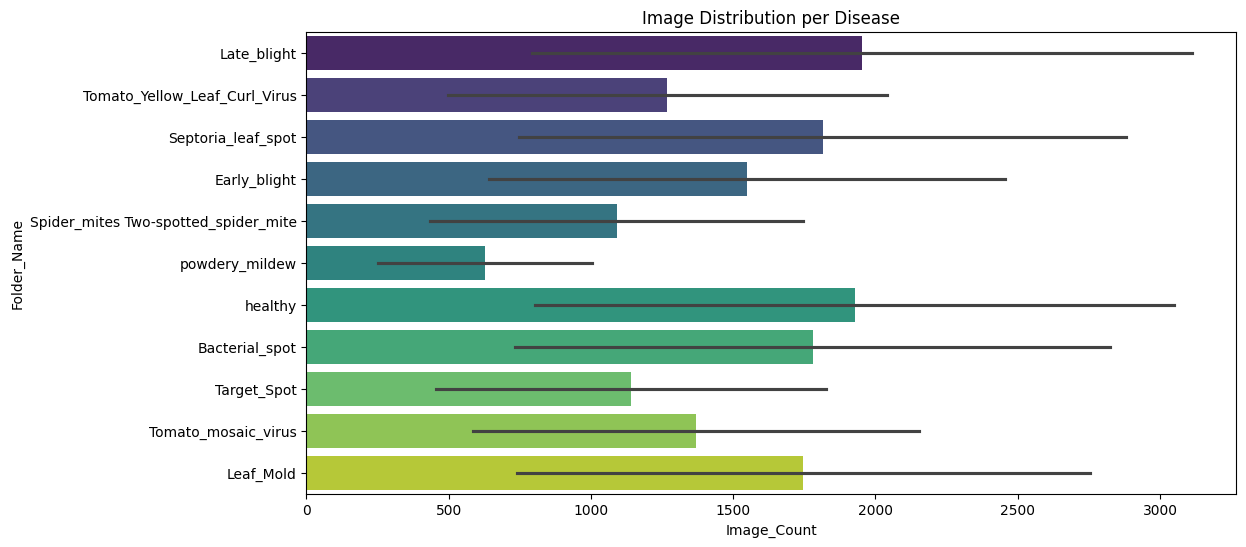

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. FIND THE DATASET PATH
input_path = '/kaggle/input/'
print("🔍 Searching for dataset folders...")
datasets = [d for d in os.listdir(input_path)]
BASE_DIR = os.path.join(input_path, datasets[0]) 

# 2. AUDIT FOLDERS AND IMAGE COUNTS
def audit_dataset(path):
    data_list = []
    for root, dirs, files in os.walk(path):
        images = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if images:
            folder_name = os.path.basename(root)
            data_list.append({'Folder_Name': folder_name, 'Image_Count': len(images), 'Path': root})
    return pd.DataFrame(data_list)

df_audit = audit_dataset(BASE_DIR)
print("\n📊 DATASET AUDIT REPORT")
print(f"✅ Total Classes: {len(df_audit)} | Total Images: {df_audit['Image_Count'].sum()}")
display(df_audit[['Folder_Name', 'Image_Count']])

plt.figure(figsize=(12, 6))
sns.barplot(data=df_audit, x='Image_Count', y='Folder_Name', palette='viridis')
plt.title('Image Distribution per Disease')
plt.show()

In [2]:
# Identify specific folders for our split strategy
input_root = '/kaggle/input/'
all_paths = []
for root, dirs, files in os.walk(input_root):
    if 'train' in dirs and 'valid' in dirs:
        all_paths.append(root)
        break

base_dir = all_paths[0]
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'valid') # Using original 'valid' as 'test'

print(f"✅ Train Path: {train_dir}\n✅ Test Path: {test_dir}")

✅ Train Path: /kaggle/input/tomato/train
✅ Test Path: /kaggle/input/tomato/valid


In [3]:
from sklearn.model_selection import train_test_split

def get_df(path):
    data = []
    for folder in os.listdir(path):
        f_path = os.path.join(path, folder)
        if os.path.isdir(f_path):
            for img in os.listdir(f_path):
                data.append({'path': os.path.join(f_path, img), 'label': folder})
    return pd.DataFrame(data)

# Load and Split (80% Train, 20% Val from the 'train' folder)
full_train_df = get_df(train_dir)
test_df = get_df(test_dir)

train_df, val_df = train_test_split(
    full_train_df, test_size=0.20, stratify=full_train_df['label'], random_state=42
)

print(f"📊 PIPELINE SUMMARY:\n• Train: {len(train_df)}\n• Val:   {len(val_df)}\n• Test:  {len(test_df)}")

📊 PIPELINE SUMMARY:
• Train: 20680
• Val:   5171
• Test:  6683


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 64

# Training with Professional Augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30, width_shift_range=0.2, height_shift_range=0.2,
    shear_range=0.2, zoom_range=0.2, horizontal_flip=True, fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_dataframe(
    train_df, x_col='path', y_col='label', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')

val_generator = val_test_datagen.flow_from_dataframe(
    val_df, x_col='path', y_col='label', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

test_generator = val_test_datagen.flow_from_dataframe(
    test_df, x_col='path', y_col='label', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

2026-02-07 07:51:48.581012: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770450709.007495      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770450709.136550      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770450710.083146      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770450710.083190      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770450710.083193      55 computation_placer.cc:177] computation placer alr

Found 20680 validated image filenames belonging to 11 classes.
Found 5171 validated image filenames belonging to 11 classes.
Found 6683 validated image filenames belonging to 11 classes.


In [7]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, callbacks

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False 

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(11, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
              loss='categorical_crossentropy', metrics=['accuracy'])

In [8]:
lr_reduce = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-7, verbose=1)
checkpoint = callbacks.ModelCheckpoint('best_tomato_mobilenet.h5', save_best_only=True, monitor='val_accuracy')

history = model.fit(
    train_generator, validation_data=val_generator, epochs=15, callbacks=[lr_reduce, checkpoint]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


I0000 00:00:1770450872.216339     132 service.cc:152] XLA service 0x7acf782155a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770450872.216384     132 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1770450872.216390     132 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1770450873.522640     132 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-02-07 07:54:43.337353: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-07 07:54:43.476358: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1770450886.447333     132 device_co

272/324 ━━━━━━━━━━━━━━━━━━━━ 1:04 1s/step - accuracy: 0.5473 - loss: 1.3887

2026-02-07 08:00:31.558406: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-07 08:00:31.702172: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-07 08:00:31.838283: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


...

324/324 ━━━━━━━━━━━━━━━━━━━━ 276s 853ms/step - accuracy: 0.8801 - loss: 0.3400 - val_accuracy: 0.8836 - val_loss: 0.3329 - learning_rate: 2.0000e-04
Epoch 11/15
324/324 ━━━━━━━━━━━━━━━━━━━━ 0s 784ms/step - accuracy: 0.8858 - loss: 0.3268

324/324 ━━━━━━━━━━━━━━━━━━━━ 273s 841ms/step - accuracy: 0.8858 - loss: 0.3268 - val_accuracy: 0.8936 - val_loss: 0.3204 - learning_rate: 2.0000e-04
Epoch 12/15
324/324 ━━━━━━━━━━━━━━━━━━━━ 0s 814ms/step - accuracy: 0.8958 - loss: 0.3035

324/324 ━━━━━━━━━━━━━━━━━━━━ 288s 888ms/step - accuracy: 0.8958 - loss: 0.3035 - val_accuracy: 0.8942 - val_loss: 0.3192 - learning_rate: 2.0000e-04
Epoch 13/15
324/324 ━━━━━━━━━━━━━━━━━━━━ 0s 832ms/step - accuracy: 0.8982 - loss: 0.2981

324/324 ━━━━━━━━━━━━━━━━━━━━ 296s 914ms/step - accuracy: 0.8982 - loss: 0.2981 - val_accuracy: 0.8977 - val_loss: 0.3121 - learning_rate: 2.0000e-04
Epoch 14/15
324/324 ━━━━━━━━━━━━━━━━━━━━ 0s 844ms/step - accuracy: 0.8973 - loss: 0.2966

324/324 ━━━━━━━━━━━━━━━━━━━━ 298s 919ms/step - accuracy: 0.8973 - loss: 0.2966 - val_accuracy: 0.8979 - val_loss: 0.3016 - learning_rate: 2.0000e-04
Epoch 15/15
324/324 ━━━━━━━━━━━━━━━━━━━━ 290s 896ms/step - accuracy: 0.9010 - loss: 0.2780 - val_accuracy: 0.8929 - val_loss: 0.3193 - learning_rate: 2.0000e-04


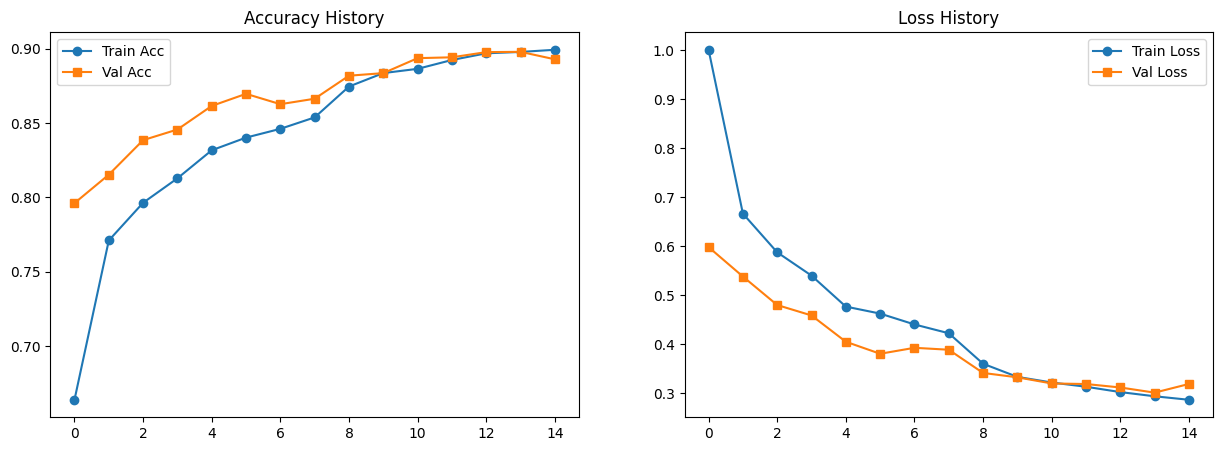

In [9]:
def plot_history(history):
    acc, val_acc = history.history['accuracy'], history.history['val_accuracy']
    loss, val_loss = history.history['loss'], history.history['val_loss']
    
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1); plt.plot(acc, label='Train Acc', marker='o'); plt.plot(val_acc, label='Val Acc', marker='s'); plt.title('Accuracy History'); plt.legend()
    plt.subplot(1, 2, 2); plt.plot(loss, label='Train Loss', marker='o'); plt.plot(val_loss, label='Val Loss', marker='s'); plt.title('Loss History'); plt.legend()
    plt.savefig('training_history.png'); plt.show()

plot_history(history)

In [10]:
print("🎯 EVALUATING ON TEST SET (VALID FOLDER)...")
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"\n✅ FINAL TEST ACCURACY: {test_acc*100:.2f}%")

🎯 EVALUATING ON TEST SET (VALID FOLDER)...
104/105 ━━━━━━━━━━━━━━━━━━━━ 0s 664ms/step - accuracy: 0.9084 - loss: 0.2914

2026-02-07 09:15:26.284859: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-07 09:15:26.422336: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


105/105 ━━━━━━━━━━━━━━━━━━━━ 78s 751ms/step - accuracy: 0.9082 - loss: 0.2917

✅ FINAL TEST ACCURACY: 89.97%


105/105 ━━━━━━━━━━━━━━━━━━━━ 35s 290ms/step


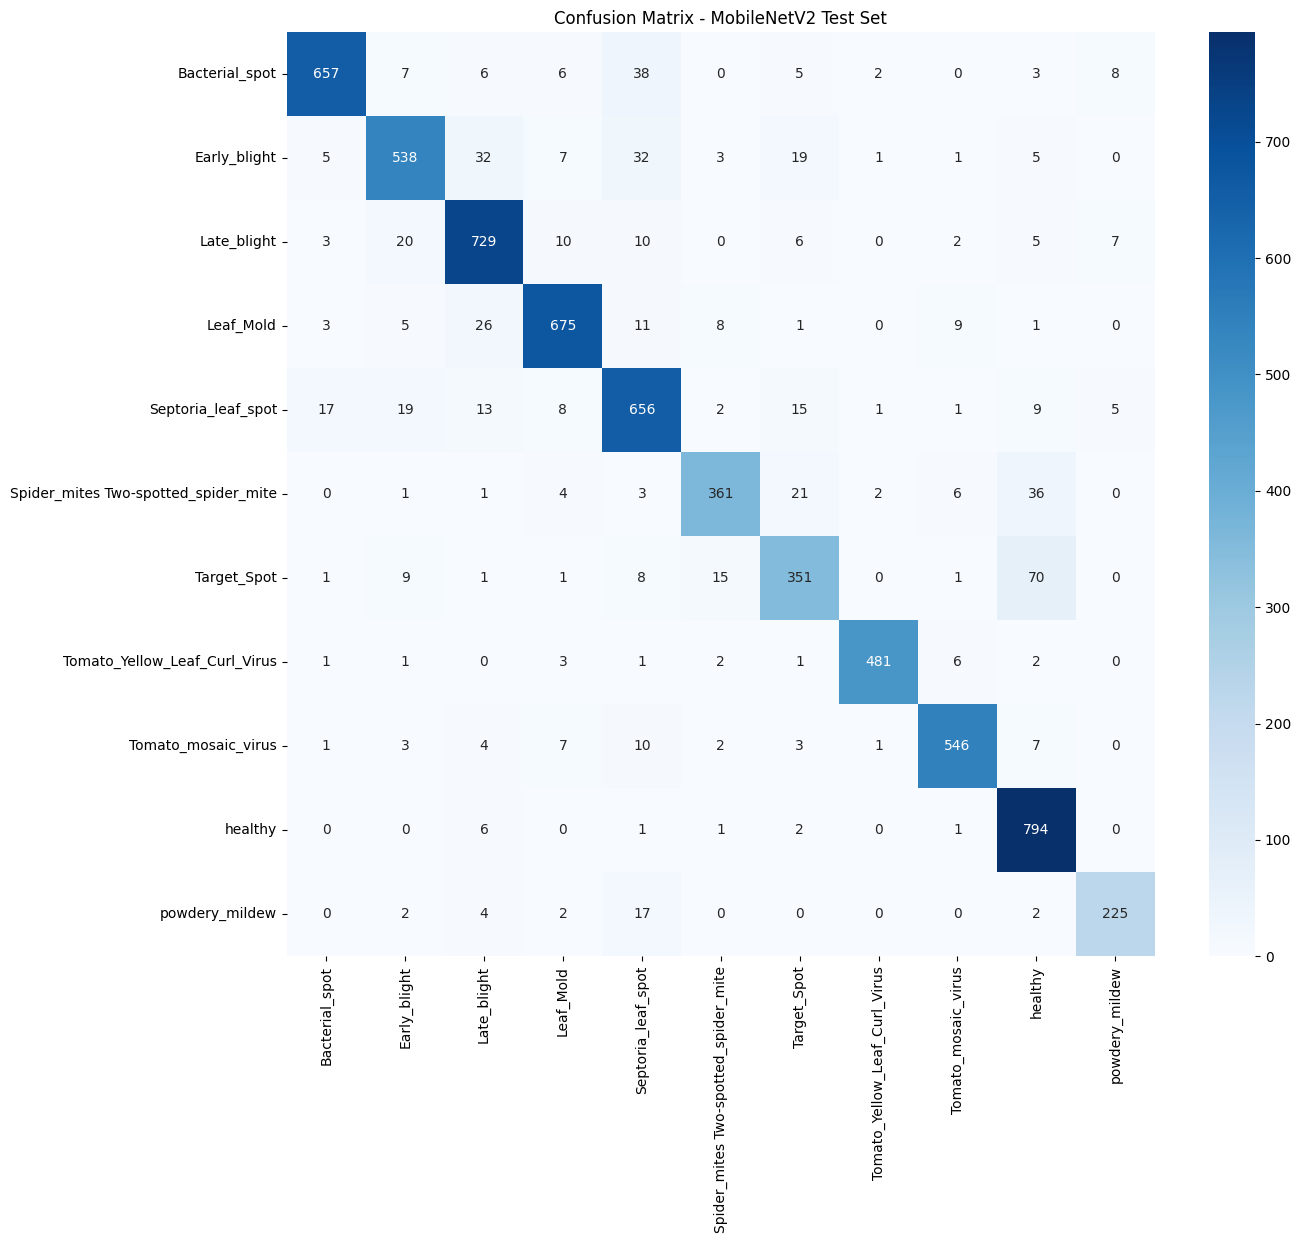

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

test_generator.reset()
Y_pred = model.predict(test_generator, verbose=1)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

plt.figure(figsize=(14, 12))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - MobileNetV2 Test Set'); plt.savefig('confusion_matrix.png'); plt.show()

In [12]:
print("📋 CLASSIFICATION REPORT\n" + "="*40)
print(classification_report(y_true, y_pred, target_names=class_labels))
pd.DataFrame(classification_report(y_true, y_pred, target_names=class_labels, output_dict=True)).transpose().to_csv('report.csv')

📋 CLASSIFICATION REPORT
                                      precision    recall  f1-score   support

                      Bacterial_spot       0.95      0.90      0.93       732
                        Early_blight       0.89      0.84      0.86       643
                         Late_blight       0.89      0.92      0.90       792
                           Leaf_Mold       0.93      0.91      0.92       739
                  Septoria_leaf_spot       0.83      0.88      0.86       746
Spider_mites Two-spotted_spider_mite       0.92      0.83      0.87       435
                         Target_Spot       0.83      0.77      0.80       457
       Tomato_Yellow_Leaf_Curl_Virus       0.99      0.97      0.98       498
                 Tomato_mosaic_virus       0.95      0.93      0.94       584
                             healthy       0.85      0.99      0.91       805
                      powdery_mildew       0.92      0.89      0.91       252

                            accuracy  

2026-02-07 09:18:07.335116: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-07 09:18:07.472649: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


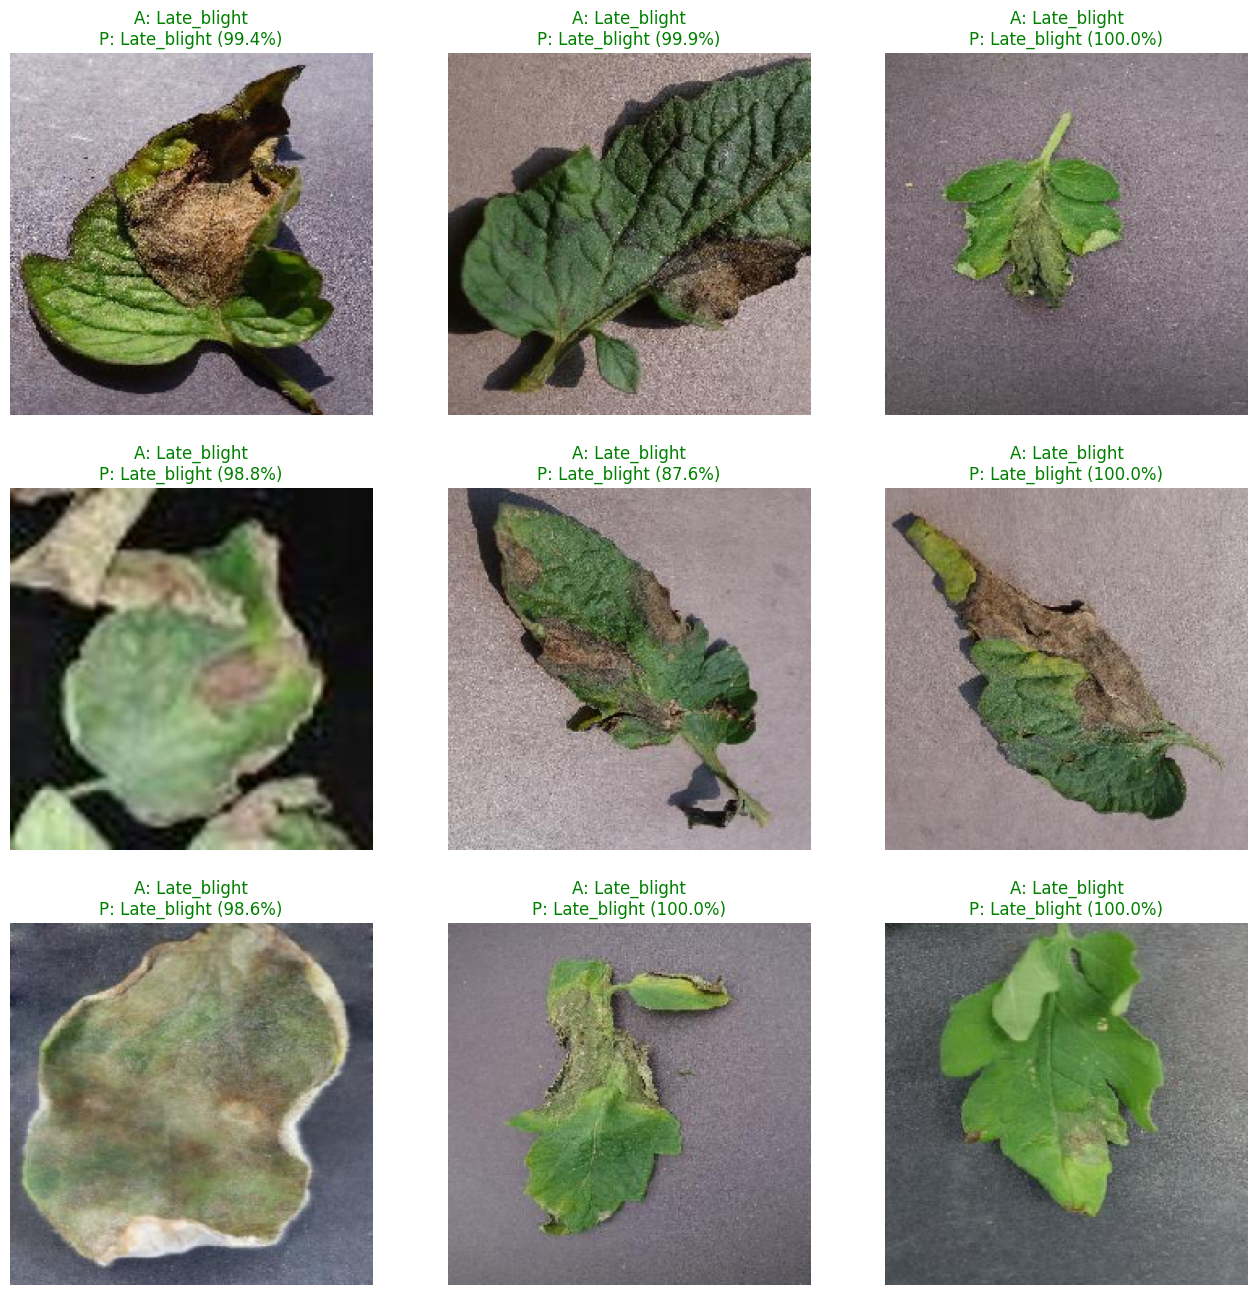

In [13]:
def visualize_preds(generator, model, names):
    imgs, lbls = next(generator)
    preds = model.predict(imgs, verbose=0)
    plt.figure(figsize=(16, 16))
    for i in range(9):
        plt.subplot(3, 3, i+1); plt.imshow(np.clip((imgs[i]+1)/2, 0, 1))
        p_idx, a_idx = np.argmax(preds[i]), np.argmax(lbls[i])
        plt.title(f"A: {names[a_idx]}\nP: {names[p_idx]} ({np.max(preds[i])*100:.1f}%)", color='green' if p_idx==a_idx else 'red')
        plt.axis('off')
    plt.savefig('samples.png'); plt.show()

visualize_preds(test_generator, model, class_labels)

In [14]:
model.save('tomato_mobilenet_final.h5')
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
with open('tomato_mobilenet.tflite', 'wb') as f: f.write(converter.convert())
print("✅ Models Saved: H5 and TFLite!")

INFO:tensorflow:Assets written to: /tmp/tmph3wh8_is/assets


INFO:tensorflow:Assets written to: /tmp/tmph3wh8_is/assets


Saved artifact at '/tmp/tmph3wh8_is'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_480')
Output Type:
  TensorSpec(shape=(None, 11), dtype=tf.float32, name=None)
Captures:
  135036684031312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135034581190032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135034581190224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135034581189648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135034581191184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135034581188880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135034581190800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135034581190992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135034581189840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135034581192144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135034581

W0000 00:00:1770455918.442853      55 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1770455918.442893      55 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1770455918.587397      55 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


In [15]:
print(f"🎉 PROJECT COMPLETE!\nTest Acc: {test_acc*100:.2f}%\nClasses: {len(class_labels)}\nSaved files: H5, TFLite, History, CM, Report")

🎉 PROJECT COMPLETE!
Test Acc: 89.97%
Classes: 11
Saved files: H5, TFLite, History, CM, Report
